Importing the necessary libraries

In [1]:
# Importing libraries
import numpy as np # For numerical operations
import pandas as pd # For loading and working with data
import matplotlib.pyplot as plt # For creating charts
import seaborn as sns # For statistical visualizations
import sklearn as sk # For preparing data and building machine-learning models
import tensorflow as tf # For building neural networks

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Models
from sklearn.neighbors import KNeighborsClassifier

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# Keras
from tensorflow.keras import layers, models, callbacks


In [2]:
dataset = pd.read_csv('Bank_marketing.csv')

In [3]:
dataset.head()

,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"56;""housemaid"";""married"";""basic.4y"";""no"";""no"";..."
1,"57;""services"";""married"";""high.school"";""unknown..."
2,"37;""services"";""married"";""high.school"";""no"";""ye..."
3,"40;""admin."";""married"";""basic.6y"";""no"";""no"";""no..."
4,"56;""services"";""married"";""high.school"";""no"";""no..."


In [4]:
dataset = pd.read_csv('Bank_marketing.csv', sep = ';')

In [5]:
dataset.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
dataset.shape

(41188, 21)

In [7]:
dataset.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [8]:
dataset.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [10]:

cat_cols = dataset.select_dtypes(include=['object'])
cat_cols

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,no
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,no
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,no
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,no
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,no
...,...,...,...,...,...,...,...,...,...,...,...
41183,retired,married,professional.course,no,yes,no,cellular,nov,fri,nonexistent,yes
41184,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,no
41185,retired,married,university.degree,no,yes,no,cellular,nov,fri,nonexistent,no
41186,technician,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,yes



Now to check which columns are ordinal and nomial

In [11]:
dataset['marital'].unique()

array(['married', 'single', 'divorced', 'unknown'], dtype=object)

In [12]:
dataset['job'].unique()

array(['housemaid', 'services', 'admin.', 'blue-collar', 'technician',
       'retired', 'management', 'unemployed', 'self-employed', 'unknown',
       'entrepreneur', 'student'], dtype=object)

In [13]:
dataset['education'].unique()

array(['basic.4y', 'high.school', 'basic.6y', 'basic.9y',
       'professional.course', 'unknown', 'university.degree',
       'illiterate'], dtype=object)

In [14]:
dataset['default'].unique()

array(['no', 'unknown', 'yes'], dtype=object)

In [15]:
dataset['housing'].unique()

array(['no', 'yes', 'unknown'], dtype=object)

In [16]:
dataset['loan'].unique()

array(['no', 'yes', 'unknown'], dtype=object)

In [17]:
dataset['contact'].unique()

array(['telephone', 'cellular'], dtype=object)

In [18]:
dataset['month'].unique()

array(['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr',
       'sep'], dtype=object)

In [19]:
dataset['day_of_week'].unique()

array(['mon', 'tue', 'wed', 'thu', 'fri'], dtype=object)

In [20]:
dataset['poutcome'].unique()

array(['nonexistent', 'failure', 'success'], dtype=object)

In [21]:
dataset['y'].unique()

array(['no', 'yes'], dtype=object)

Compiling Ordinal and Nominal columns

In [22]:
# Ordinal columns
ord_cols = ['education', 'default', 'housing', 'loan', 'poutcome']


In [23]:
# Nominal columns
oneh_cols = ['marital', 'job', 'contact', 'month', 'day_of_week', 'y']

In [24]:
# for coloumns with order - ord_cols = ['education', 'default', 'housing', 'loan', 'poutcome']
#  for columns with no order - oneh_cols = ['marital', 'job', 'contact', 'month', 'day_of_wee', 'duration'] 'ord_cols', 'oneh_cols'

In [25]:
# To check the columns with only numeric values
num_cols = dataset.select_dtypes(include=['float64', 'int64'])
num_cols

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,-1.1,94.767,-50.8,1.028,4963.6
41184,46,383,1,999,0,-1.1,94.767,-50.8,1.028,4963.6
41185,56,189,2,999,0,-1.1,94.767,-50.8,1.028,4963.6
41186,44,442,1,999,0,-1.1,94.767,-50.8,1.028,4963.6


In [26]:
dataset.isnull().any()

,0
age,False
job,False
marital,False
education,False
default,False
housing,False
loan,False
contact,False
month,False
day_of_week,False


Basic EDA Visualizations

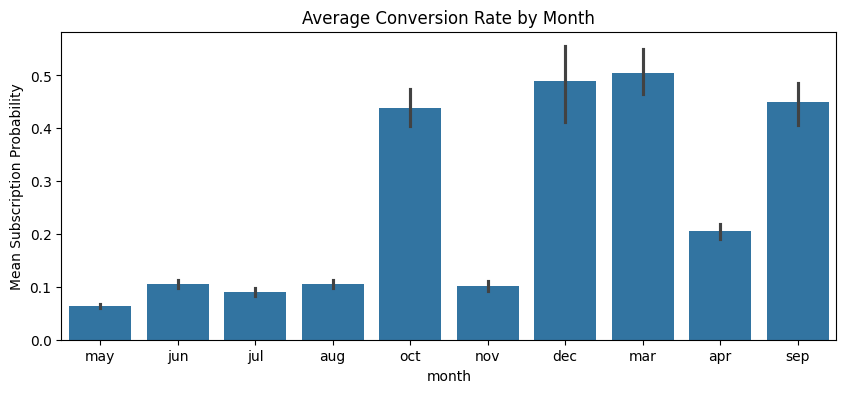

In [27]:

# Conversion by month
plt.figure(figsize=(10,4))
sns.barplot(x='month', y=dataset['y'].map({'no':0,'yes':1}), data=dataset, estimator=np.mean)
plt.title('Average Conversion Rate by Month')
plt.ylabel('Mean Subscription Probability')
plt.show()


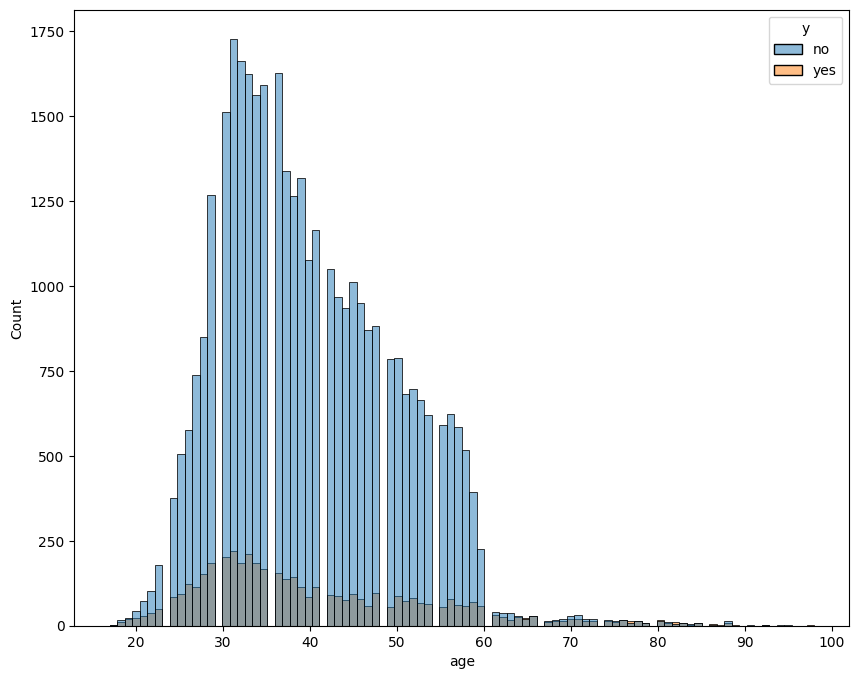

In [28]:
# Age range of customers
plt.figure(figsize=(10,8))
sns.histplot(x = dataset.age, hue = 'y' , data = dataset)
plt.show()

Addressing Class Imbalance

In [29]:
# Value count
dataset['y'].value_counts()

,count
y,
no,36548
yes,4640


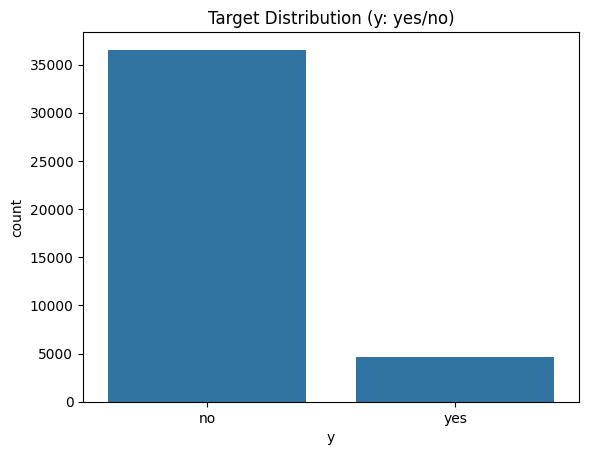

In [30]:
# Distribution of target variable
sns.countplot(x='y', data=dataset)
plt.title('Target Distribution (y: yes/no)')
plt.show()


Encode target and features

In [31]:
from sklearn import preprocessing

# Categorical columns for one hot encoding
oneh_cols = dataset.select_dtypes(include=['object']).columns.drop('y')

# Encode target
y = dataset['y'].map({'yes':1, 'no':0})

# One hot encode categorical variables
enc = preprocessing.OneHotEncoder(drop='first')
one_hot = enc.fit_transform(dataset[oneh_cols]).toarray()

# Get new column names
new_cols = enc.get_feature_names_out(oneh_cols)

# Build full numeric dataset
dataset_encoded = pd.concat([
    dataset.drop(oneh_cols, axis=1).drop('y', axis=1).reset_index(drop=True),
    pd.DataFrame(one_hot, columns=new_cols)], axis=1)

dataset_encoded['y'] = y


Preparing Data for Classification

In [32]:
# Prepare X and y
X = dataset_encoded.drop('y', axis=1)
y = dataset_encoded['y'].astype(int)

# Quick sanity:
print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (41188, 53)
y distribution:
 y
0    36548
1     4640
Name: count, dtype: int64


In [33]:
#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0)

Now to Scale the data

In [34]:
# Scale numerical features
X_train = X_train.copy()
X_test  = X_test.copy()
bool_cols = X_train.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    X_train[bool_cols] = X_train[bool_cols].astype(int)
    X_test[bool_cols]  = X_test[bool_cols].astype(int)

# Fit scaler on whole X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Check for non-numericals or NaNs proir to SMOTE

In [35]:
print("Any NaNs in X_train:", X_train.isnull().any().any())
print("Dtypes in X_train:", X_train.dtypes.unique())


Any NaNs in X_train: False
Dtypes in X_train: [dtype('int64') dtype('float64')]


Now to carry out Oversampling (SMOTE)

In [36]:
#Appling SMOTE on the Scaled training data
sm = SMOTE(random_state=0)
X_resampled, y_resampled = sm.fit_resample(X_train_scaled, y_train)

print("Before SMOTE (train):", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE (train): {0: 29238, 1: 3712}
After SMOTE: {0: 29238, 1: 29238}


SMOTE was applied to balance the training set before hyperparameter tuning, because optimizing F1 for the minority class (yes) is critical for campaign ROI

KNN Classification

In [37]:
#KNN: quick hyperparameter search

# Grid search
param_grid = {'n_neighbors':[2,3,4,5,],
}

knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=3, scoring='f1', n_jobs=-1)   # optimize F1 for minority class
grid.fit(X_resampled, y_resampled)

print("Best k:", grid.best_params_)
best_knn = grid.best_estimator_

Best k: {'n_neighbors': 2}


KNN test accuracy: 0.8753338188880796
KNN classification report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      7310
           1       0.44      0.43      0.44       928

    accuracy                           0.88      8238
   macro avg       0.69      0.68      0.68      8238
weighted avg       0.87      0.88      0.87      8238



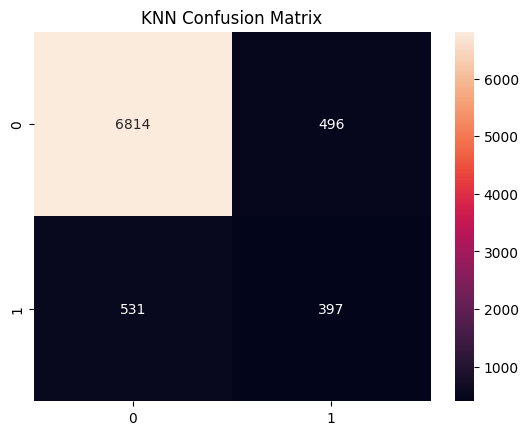

In [38]:
# Evaluate on test set
y_pred_knn = best_knn.predict(X_test_scaled)
print("KNN test accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN classification report:\n", classification_report(y_test, y_pred_knn))
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d'); plt.title("KNN Confusion Matrix"); plt.show()

Predict & evaluate (classification report & confusion matrix)

NEURAL NETWORK (Keras)

Building and Training our Neural Network

In [39]:
X_train.shape

(32950, 53)

In [40]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(32,activation='relu',input_shape=(53,)))
model.add(tf.keras.layers.Dense(16,activation='relu'))
model.add(tf.keras.layers.Dense(8,activation='relu'))
model.add(tf.keras.layers.Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.compile(optimizer='adam', loss='binary_crossentropy',metrics= ['accuracy'])

In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,401 (9.38 KB)

 Trainable params: 2,401 (9.38 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
class_weights = { 0:1, 1:4}
history = model.fit(X_resampled, np.asarray(y_resampled), batch_size = 16, epochs= 30,verbose=2, class_weight=class_weights, validation_split=0.2)

Epoch 1/30
2924/2924 - 9s - 3ms/step - accuracy: 0.8384 - loss: 0.5480 - val_accuracy: 0.9826 - val_loss: 0.0969
Epoch 2/30
2924/2924 - 9s - 3ms/step - accuracy: 0.8719 - loss: 0.4409 - val_accuracy: 0.9902 - val_loss: 0.0755
Epoch 3/30
2924/2924 - 7s - 2ms/step - accuracy: 0.8769 - loss: 0.4202 - val_accuracy: 0.9887 - val_loss: 0.0908
Epoch 4/30
2924/2924 - 8s - 3ms/step - accuracy: 0.8819 - loss: 0.4042 - val_accuracy: 0.9877 - val_loss: 0.0751
Epoch 5/30
2924/2924 - 7s - 2ms/step - accuracy: 0.8856 - loss: 0.3928 - val_accuracy: 0.9837 - val_loss: 0.1013
Epoch 6/30
2924/2924 - 8s - 3ms/step - accuracy: 0.8884 - loss: 0.3823 - val_accuracy: 0.9925 - val_loss: 0.0652
Epoch 7/30
2924/2924 - 11s - 4ms/step - accuracy: 0.8908 - loss: 0.3735 - val_accuracy: 0.9865 - val_loss: 0.0811
Epoch 8/30
2924/2924 - 7s - 2ms/step - accuracy: 0.8942 - loss: 0.3637 - val_accuracy: 0.9933 - val_loss: 0.0562
Epoch 9/30
2924/2924 - 8s - 3ms/step - accuracy: 0.8974 - loss: 0.3578 - val_accuracy: 0.9852 -

Evaluating The Neural Network

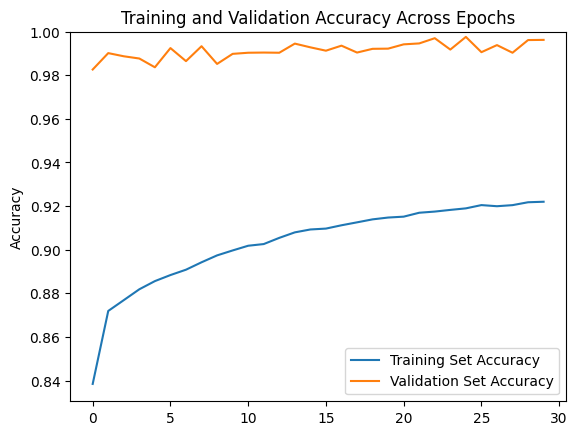

In [44]:
accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
plt.plot(accuracy, label='Training Set Accuracy')
plt.plot(validation_accuracy, label='Validation Set Accuracy')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy Across Epochs')
plt.legend()

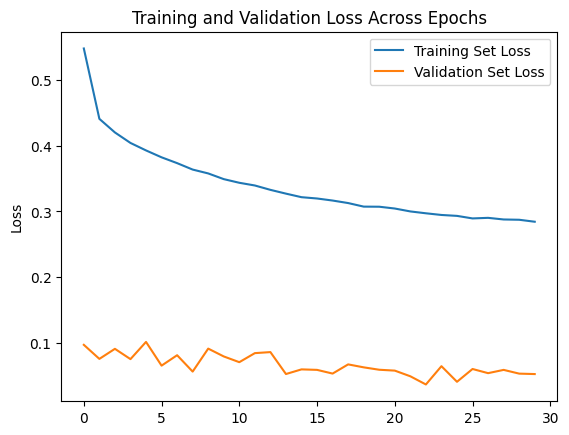

In [45]:
loss = history.history['loss']
validation_loss = history.history['val_loss']

plt.plot(loss, label='Training Set Loss')
plt.plot(validation_loss, label='Validation Set Loss')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs')
plt.legend()

Confusion matrix

In [46]:
from sklearn.metrics import confusion_matrix, classification_report

In [47]:
y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)

258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


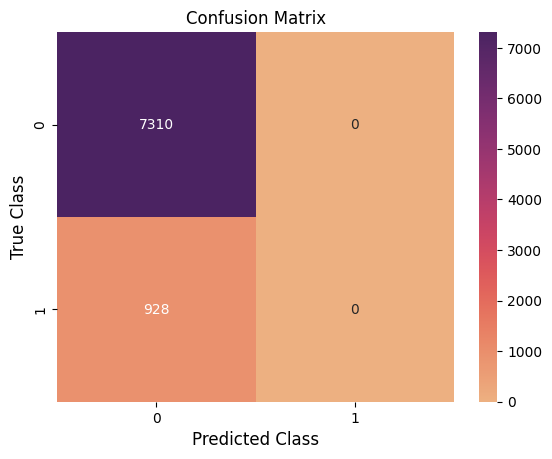

In [48]:
confusion_matrix = confusion_matrix(y_test,y_pred)
ax = sns.heatmap(confusion_matrix, cmap='flare',annot=True, fmt='d')
plt.xlabel("Predicted Class",fontsize=12)
plt.ylabel("True Class",fontsize=12)
plt.title("Confusion Matrix",fontsize=12)
plt.show()

In [49]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      7310
           1       0.00      0.00      0.00       928

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
